In [1]:
pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.5 MB/s eta 0:00:46
   ---------------------------------------- 0.8/69.5 MB 1.5 MB/s eta 0:00:47
    --------------------------------------- 1.0/69.5 MB 1.6 MB/s eta 0:00:42
    --------------------------------------- 1.6/69.5 MB 1.9 MB/s eta 0:00:37
   - -------------------------------------- 2.1/69.5 MB 2.0 MB/s eta 0:00:34
   - -------------------------------------- 2.6/69.5 MB 2.0 MB/s eta 0:00:33
   - -------------------------------------- 3.1/69.5 MB 2.1 MB/s eta 0:00:31
   -- ------------------------------------- 3.7/69.5 MB 2.1 MB/s eta 0:00:31
   -- ------------------------------------- 4.5/69.5 MB 2.2 MB/s eta 0:00:30
   --- ------------------------------------ 5.2/69.5 MB 2.4 MB/s eta 0:00:27
   --- ------------------------------------ 5.8/69.5 MB 2.4 MB/s eta 0:00:27
   --- ------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
df=pd.read_csv("../data/processed/weather_feature_engineered.csv")

In [4]:
X=df.drop(columns=["Visibility (km)"])
y=df["Visibility (km)"]

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [7]:
xgb_model=XGBRegressor(
    n_estimator=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42

)

In [8]:
xgb_model.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [9]:
y_pred=xgb_model.predict(X_test)

In [10]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

MAE      : 1.4365
MSE      : 4.1634
RMSE     : 2.0404
R² Score : 0.7646


In [11]:
comparison_df=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

comparison_df.head(10)

,Actual,Predicted
87206,15.5526,12.496329
33421,9.9820,9.146583
6807,9.6278,9.971432
37340,8.0500,7.521970
3016,7.5509,7.265618
54286,13.7977,8.096681
27660,9.9820,10.673547
6108,11.2700,10.473921
95359,4.5080,8.996690
85743,8.4203,11.275044


In [12]:
feature_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":xgb_model.feature_importances_
})
feature_importance=feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [13]:
feature_importance.head(10)

,Feature,Importance
25,Summary_Foggy,0.689797
44,Season_Summer,0.038914
10,Hour,0.038541
2,Humidity,0.036868
32,Summary_Partly Cloudy,0.033227
31,Summary_Overcast,0.030014
40,Precip Type_rain,0.023964
7,Year,0.016903
45,Season_Winter,0.014125
0,Temperature (C),0.013875


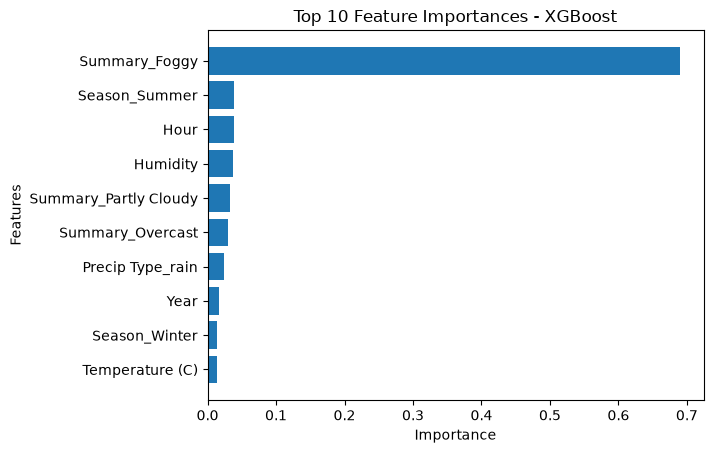

In [14]:
plt.Figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()
plt.show()

In [16]:
joblib.dump(xgb_model,"../models/xgboost_model.pkl")

['../models/xgboost_model.pkl']

In [17]:
import os
os.path.exists("../models/xgboost_model.pkl")

True

In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        2.4960,
        1.5368,
        1.1873,
        1.4365
    ],
    "RMSE": [
        3.0290,
        2.2878,
        1.8434,
        2.0404
    ],
    "R2 Score": [
        0.4813,
        0.7041,
        0.8079,
        0.7646
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.4960,3.0290,0.4813
1,Decision Tree,1.5368,2.2878,0.7041
2,Random Forest,1.1873,1.8434,0.8079
3,XGBoost,1.4365,2.0404,0.7646


In [19]:
comparison.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest,1.1873,1.8434,0.8079
3,XGBoost,1.4365,2.0404,0.7646
1,Decision Tree,1.5368,2.2878,0.7041
0,Linear Regression,2.4960,3.0290,0.4813


## Summary

In this notebook:

- Loaded the feature-engineered dataset.
- Trained an XGBoost Regressor model.
- Evaluated the model using MAE, MSE, RMSE, and R² Score.
- Analyzed the top 10 feature importances.
- Saved the trained model as `xgboost_model.pkl`.
- Compared the performance with previously trained models.

### Results

- MAE: 1.4365
- RMSE: 2.0404
- R² Score: 0.7646

Although XGBoost outperformed Linear Regression and Decision Tree, Random Forest achieved the highest R² score on this dataset. The next step is to perform hyperparameter tuning to further improve model performance.